{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


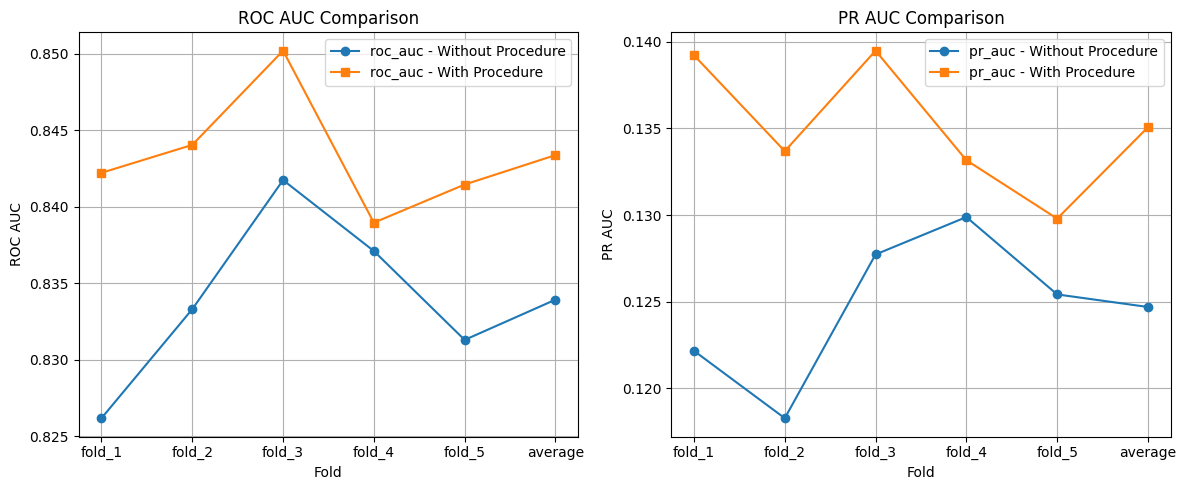

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from azureml.core import Workspace, Dataset, Datastore

# اتصال به Azure ML Workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "researcher_data")

# مسیر فایل‌های CSV روی Azure
file_path_1 = 'CorebehrtPipeline/MD/v1/XGBoost/Evaluate/Mortality/metrics.csv'
file_path_2 = 'CorebehrtPipeline/MDP/v1/XGBoost/Evaluate/Mortality/metrics.csv'

# لود دیتاست‌ها
dataset_1 = Dataset.Tabular.from_delimited_files(path=(datastore, file_path_1))
dataset_2 = Dataset.Tabular.from_delimited_files(path=(datastore, file_path_2))

df1_raw = dataset_1.to_pandas_dataframe()
df2_raw = dataset_2.to_pandas_dataframe()

# تبدیل به فرمت ساختاریافته
def reshape_metrics(df):
    # حذف ردیف‌های تایتل
    df = df.iloc[:].reset_index(drop=True)
    values = df.values.flatten()
    metrics = {"fold": [], "pr_auc": [], "roc_auc": []}
    for i in range(0, len(values), 3):
        try:
            pr = float(values[i])
            roc = float(values[i+1])
            fold = str(values[i+2])
            metrics["pr_auc"].append(pr)
            metrics["roc_auc"].append(roc)
            metrics["fold"].append(fold)
        except (ValueError, IndexError):
            # نادیده گرفتن سطرهای خراب یا "average"
            continue
    return pd.DataFrame(metrics)

# شکل‌دهی به هر دو فایل
df1 = reshape_metrics(df1_raw)
df2 = reshape_metrics(df2_raw)

# 📊 رسم نمودارها
plt.figure(figsize=(12, 5))

# ROC AUC Plot
plt.subplot(1, 2, 1)
plt.plot(df1["fold"], df1["roc_auc"], marker='o', label="roc_auc - Without Procedure")
plt.plot(df2["fold"], df2["roc_auc"], marker='s', label="roc_auc - With Procedure")
plt.title("ROC AUC Comparison")
plt.xlabel("Fold")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True)

# PR AUC Plot
plt.subplot(1, 2, 2)
plt.plot(df1["fold"], df1["pr_auc"], marker='o', label="pr_auc - Without Procedure")
plt.plot(df2["fold"], df2["pr_auc"], marker='s', label="pr_auc - With Procedure")
plt.title("PR AUC Comparison")
plt.xlabel("Fold")
plt.ylabel("PR AUC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
df1_raw

,pr_auc,roc_auc,fold
0,0.122157,0.826191,fold_1
1,0.118266,0.833317,fold_2
2,0.127723,0.841757,fold_3
3,0.129883,0.837119,fold_4
4,0.125415,0.831308,fold_5
5,0.124689,0.833938,average


In [15]:
# شکل‌دهی به dfها از raw
df1 = reshape_metrics(df1_raw)
df2 = reshape_metrics(df2_raw)

print("df1 columns:", df1.columns)  # اطمینان از ستون‌ها

# تغییر نام ستون‌ها برای merge مرتب
df1_named = df1.rename(columns={"pr_auc": "without_pr_auc", "roc_auc": "without_roc_auc"})
df2_named = df2.rename(columns={"pr_auc": "with_pr_auc", "roc_auc": "with_roc_auc"})

# merge بر اساس fold
merged = pd.merge(df1_named, df2_named, on="fold")

# ساخت جدول مقایسه‌ای ردیف‌محور
rows = []
for _, row in merged.iterrows():
    fold = row['fold']
    rows.append({
        "fold": fold,
        "metric": "pr_auc",
        "without_procedure": row["without_pr_auc"],
        "with_procedure": row["with_pr_auc"]
    })
    rows.append({
        "fold": fold,
        "metric": "roc_auc",
        "without_procedure": row["without_roc_auc"],
        "with_procedure": row["with_roc_auc"]
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df)


df1 columns: Index(['fold', 'pr_auc', 'roc_auc'], dtype='object')
       fold   metric  without_procedure  with_procedure
0    fold_1   pr_auc           0.122157        0.139227
1    fold_1  roc_auc           0.826191        0.842231
2    fold_2   pr_auc           0.118266        0.133690
3    fold_2  roc_auc           0.833317        0.844057
4    fold_3   pr_auc           0.127723        0.139490
5    fold_3  roc_auc           0.841757        0.850214
6    fold_4   pr_auc           0.129883        0.133167
7    fold_4  roc_auc           0.837119        0.838971
8    fold_5   pr_auc           0.125415        0.129792
9    fold_5  roc_auc           0.831308        0.841466
10  average   pr_auc           0.124689        0.135073
11  average  roc_auc           0.833938        0.843388


In [17]:
import pandas as pd
from tabulate import tabulate  # نصب: pip install tabulate

# ساخت df مثل قبل (فرض می‌کنیم این مرحله قبلاً انجام شده):
# df1 = reshape_metrics(...)
# df2 = reshape_metrics(...)
# merged = ...

# بازچینی بهتر: اول roc_auc بیاد
comparison_df = pd.DataFrame(rows)
comparison_df["metric"] = pd.Categorical(comparison_df["metric"], categories=["roc_auc", "pr_auc"], ordered=True)
comparison_df = comparison_df.sort_values(by=["fold", "metric"]).reset_index(drop=True)

# نمایش شکیل با tabulate
print("\n جدول مقایسه‌ای:")
print(tabulate(comparison_df, headers='keys', tablefmt='fancy_grid', showindex=False))



 جدول مقایسه‌ای:
╒═════════╤══════════╤═════════════════════╤══════════════════╕
│ fold    │ metric   │   without_procedure │   with_procedure │
╞═════════╪══════════╪═════════════════════╪══════════════════╡
│ average │ roc_auc  │            0.833938 │         0.843388 │
├─────────┼──────────┼─────────────────────┼──────────────────┤
│ average │ pr_auc   │            0.124689 │         0.135073 │
├─────────┼──────────┼─────────────────────┼──────────────────┤
│ fold_1  │ roc_auc  │            0.826191 │         0.842231 │
├─────────┼──────────┼─────────────────────┼──────────────────┤
│ fold_1  │ pr_auc   │            0.122157 │         0.139227 │
├─────────┼──────────┼─────────────────────┼──────────────────┤
│ fold_2  │ roc_auc  │            0.833317 │         0.844057 │
├─────────┼──────────┼─────────────────────┼──────────────────┤
│ fold_2  │ pr_auc   │            0.118266 │         0.13369  │
├─────────┼──────────┼─────────────────────┼──────────────────┤
│ fold_3  │ roc_auc  │

In [18]:
import pandas as pd

# ساخت df مثل قبل
comparison_df = pd.DataFrame(rows)
comparison_df["metric"] = pd.Categorical(comparison_df["metric"], categories=["roc_auc", "pr_auc"], ordered=True)
comparison_df = comparison_df.sort_values(by=["fold", "metric"]).reset_index(drop=True)

# تنظیم نمایش همه ردیف‌ها بدون اسکرول
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# استایل برای نمایش شفاف و خوانا در نوت‌بوک
styled = comparison_df.style.set_caption("🔍 جدول مقایسه‌ای ROC/PR AUC").background_gradient(cmap='Blues', axis=1)

# نمایش در نوت‌بوک
styled


,fold,metric,without_procedure,with_procedure
0,average,roc_auc,0.833938,0.843388
1,average,pr_auc,0.124689,0.135073
2,fold_1,roc_auc,0.826191,0.842231
3,fold_1,pr_auc,0.122157,0.139227
4,fold_2,roc_auc,0.833317,0.844057
5,fold_2,pr_auc,0.118266,0.133690
6,fold_3,roc_auc,0.841757,0.850214
7,fold_3,pr_auc,0.127723,0.139490
8,fold_4,roc_auc,0.837119,0.838971
9,fold_4,pr_auc,0.129883,0.133167
